<a href="https://colab.research.google.com/github/SarahBour/ROGII---Wellbore-Geology-Prediction/blob/main/rogii_wellbore_geology_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dependencies

In [ ]:
# import all libraries and functions here ...
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
from scipy.signal import correlate
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# 2. Exploratory Data Analysis

In [ ]:
# constants
#directories
DATA_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

#files
HORIZONTAL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__horizontal_well.csv"))
TYPEWELL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__typewell.csv"))

WINDOW = 25 # for cross correlation
ROLLING_WINDOW = 30

In [ ]:
# code to see all files in the data/ input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [ ]:
# check horizontal csv file
def get_horizontal_file():
    file_path = random.choice(HORIZONTAL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df, well_ID

In [ ]:
# check typewell csv file
def get_typewell_file():
    file_path = random.choice(TYPEWELL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df

In [ ]:
# get matching typewell file
def get_matching_files():
    horizontal_df, well_ID  = get_horizontal_file()
    typewell_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    typewell_df = pd.read_csv(typewell_file)
    return horizontal_df, well_ID,typewell_df

In [ ]:
h_df, ID , tw_df = get_matching_files()

In [ ]:
h_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10405.0,3006373.50,1122241.90,-8268.88,-8841.06,-8975.41,-9057.97,-9192.49,-9243.04,-9348.92,10361.84,NaN,10361.84,f8f59188
1,10406.0,3006373.50,1122241.89,-8269.88,-8841.04,-8975.39,-9057.95,-9192.47,-9243.02,-9348.90,10362.86,NaN,10362.86,f8f59188
2,10407.0,3006373.49,1122241.88,-8270.88,-8841.02,-8975.37,-9057.93,-9192.45,-9243.00,-9348.88,10363.88,NaN,10363.88,f8f59188
3,10408.0,3006373.49,1122241.87,-8271.88,-8841.00,-8975.35,-9057.91,-9192.43,-9242.98,-9348.85,10364.91,NaN,10364.91,f8f59188
4,10409.0,3006373.48,1122241.86,-8272.88,-8840.98,-8975.33,-9057.88,-9192.41,-9242.96,-9348.83,10365.93,NaN,10365.93,f8f59188


In [ ]:
tw_df.head()

,TVT,GR,Geology
0,10349.47,121.38,NaN
1,10349.97,117.78,NaN
2,10350.47,114.49,NaN
3,10350.97,115.79,NaN
4,10351.47,119.42,NaN


In [ ]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6740 entries, 0 to 6739
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         6740 non-null   float64
 1   X          6740 non-null   float64
 2   Y          6740 non-null   float64
 3   Z          6740 non-null   float64
 4   ANCC       6740 non-null   float64
 5   ASTNU      6740 non-null   float64
 6   ASTNL      6740 non-null   float64
 7   EGFDU      6740 non-null   float64
 8   EGFDL      6740 non-null   float64
 9   BUDA       6740 non-null   float64
 10  TVT        6740 non-null   float64
 11  GR         2591 non-null   float64
 12  TVT_input  1933 non-null   float64
 13  WELL_ID    6740 non-null   object 
dtypes: float64(13), object(1)
memory usage: 737.3+ KB


In [ ]:
h_df.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,6740.000000,6.740000e+03,6.740000e+03,6740.000000,6740.000000,6740.000000,6740.000000,6740.00000,6740.000000,6740.000000,6740.000000,2591.000000,1933.000000
mean,13774.500000,3.006448e+06,1.125054e+06,-9036.155826,-8727.789007,-8862.139310,-8944.697574,-9079.22108,-9129.768703,-9235.645823,11242.389286,76.959844,11064.868246
std,1945.814739,4.360097e+01,1.896109e+03,166.350017,65.255733,65.255762,65.255761,65.25581,65.255739,65.255774,193.202100,18.251768,293.137342
min,10405.000000,3.006371e+06,1.122241e+06,-9171.440000,-8841.060000,-8975.410000,-9057.970000,-9192.49000,-9243.040000,-9348.920000,10361.840000,35.247312,10361.840000
25%,12089.750000,3.006424e+06,1.123341e+06,-9136.170000,-8785.612500,-8919.962500,-9002.515000,-9137.04250,-9187.585000,-9293.462500,11306.407500,66.255073,10867.100000
50%,13774.500000,3.006448e+06,1.125024e+06,-9073.795000,-8736.110000,-8870.460000,-8953.020000,-9087.54000,-9138.090000,-9243.960000,11310.830000,75.109833,11209.800000
75%,15459.250000,3.006469e+06,1.126706e+06,-9021.480000,-8663.500000,-8797.850000,-8880.402500,-9014.93000,-9065.472500,-9171.350000,11314.560000,81.764320,11303.960000
max,17144.000000,3.006528e+06,1.128388e+06,-8268.880000,-8616.950000,-8751.300000,-8833.860000,-8968.39000,-9018.930000,-9124.810000,11323.980000,168.143848,11308.970000


In [ ]:
tw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2378 entries, 0 to 2377
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      2378 non-null   float64
 1   GR       2378 non-null   float64
 2   Geology  1208 non-null   object 
dtypes: float64(2), object(1)
memory usage: 55.9+ KB


In [ ]:
tw_df['Geology']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
2373    BUDA
2374    BUDA
2375    BUDA
2376    BUDA
2377    BUDA
Name: Geology, Length: 2378, dtype: object

In [ ]:
# another well
h_df_1, _, tw_df_1 = get_matching_files()

In [ ]:
h_df_1.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,11532.0,3011950.74,1110561.29,-9244.35,-9402.25,-9558.47,-9631.41,-9765.97,-9810.00,-9930.09,11409.78,95.680865,11409.78,2f8e53c3
1,11533.0,3011950.73,1110561.29,-9245.35,-9402.24,-9558.46,-9631.40,-9765.96,-9810.00,-9930.09,11410.79,94.283104,11410.79,2f8e53c3
2,11534.0,3011950.73,1110561.28,-9246.35,-9402.23,-9558.45,-9631.39,-9765.95,-9809.99,-9930.08,11411.80,95.837086,11411.80,2f8e53c3
3,11535.0,3011950.72,1110561.28,-9247.35,-9402.22,-9558.44,-9631.39,-9765.94,-9809.98,-9930.07,11412.81,103.097222,11412.81,2f8e53c3
4,11536.0,3011950.72,1110561.27,-9248.35,-9402.21,-9558.43,-9631.38,-9765.93,-9809.97,-9930.06,11413.82,100.013925,11413.82,2f8e53c3


In [ ]:
h_df_1.shape

(4133, 14)

In [ ]:
h_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4133 entries, 0 to 4132
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         4133 non-null   float64
 1   X          4133 non-null   float64
 2   Y          4133 non-null   float64
 3   Z          4133 non-null   float64
 4   ANCC       4133 non-null   float64
 5   ASTNU      4133 non-null   float64
 6   ASTNL      4133 non-null   float64
 7   EGFDU      4133 non-null   float64
 8   EGFDL      4133 non-null   float64
 9   BUDA       4133 non-null   float64
 10  TVT        4133 non-null   float64
 11  GR         2678 non-null   float64
 12  TVT_input  1539 non-null   float64
 13  WELL_ID    4133 non-null   object 
dtypes: float64(13), object(1)
memory usage: 452.2+ KB


In [ ]:
tw_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3039 entries, 0 to 3038
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      3039 non-null   float64
 1   GR       3039 non-null   float64
 2   Geology  2358 non-null   object 
dtypes: float64(2), object(1)
memory usage: 71.4+ KB


In [ ]:
def plot_x_y(x, y, x_label , y_label, title):
    plt.figure(figsize = (20,8))
    plt.plot(x, y, linewidth = 0.8)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha = 0.3)
    plt.show()

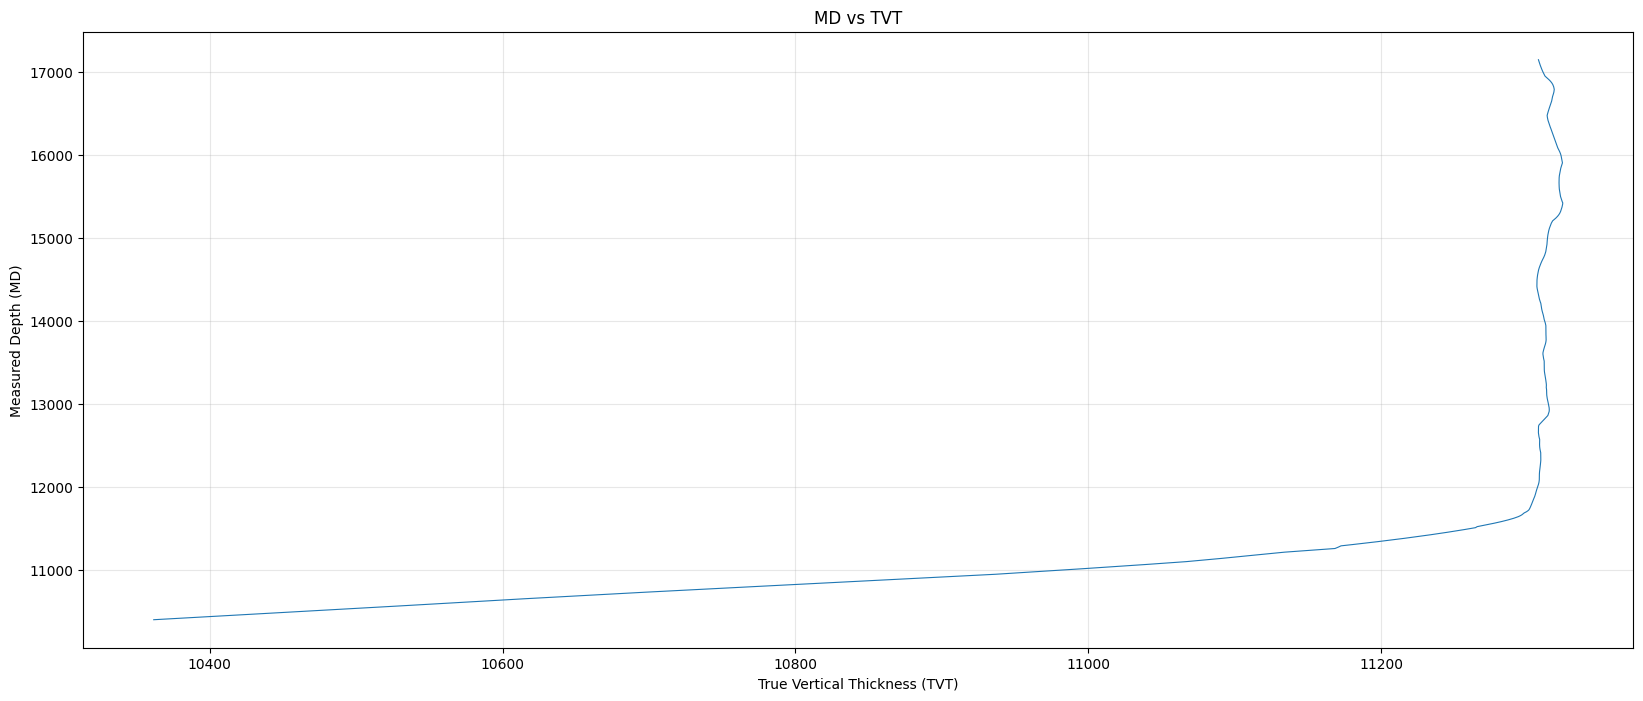

In [ ]:
# MD against TVT
# illustrates where the horizontal drilling starts (?)
plot_x_y(h_df['TVT'], h_df['MD'], "True Vertical Thickness (TVT)", "Measured Depth (MD)", "MD vs TVT")

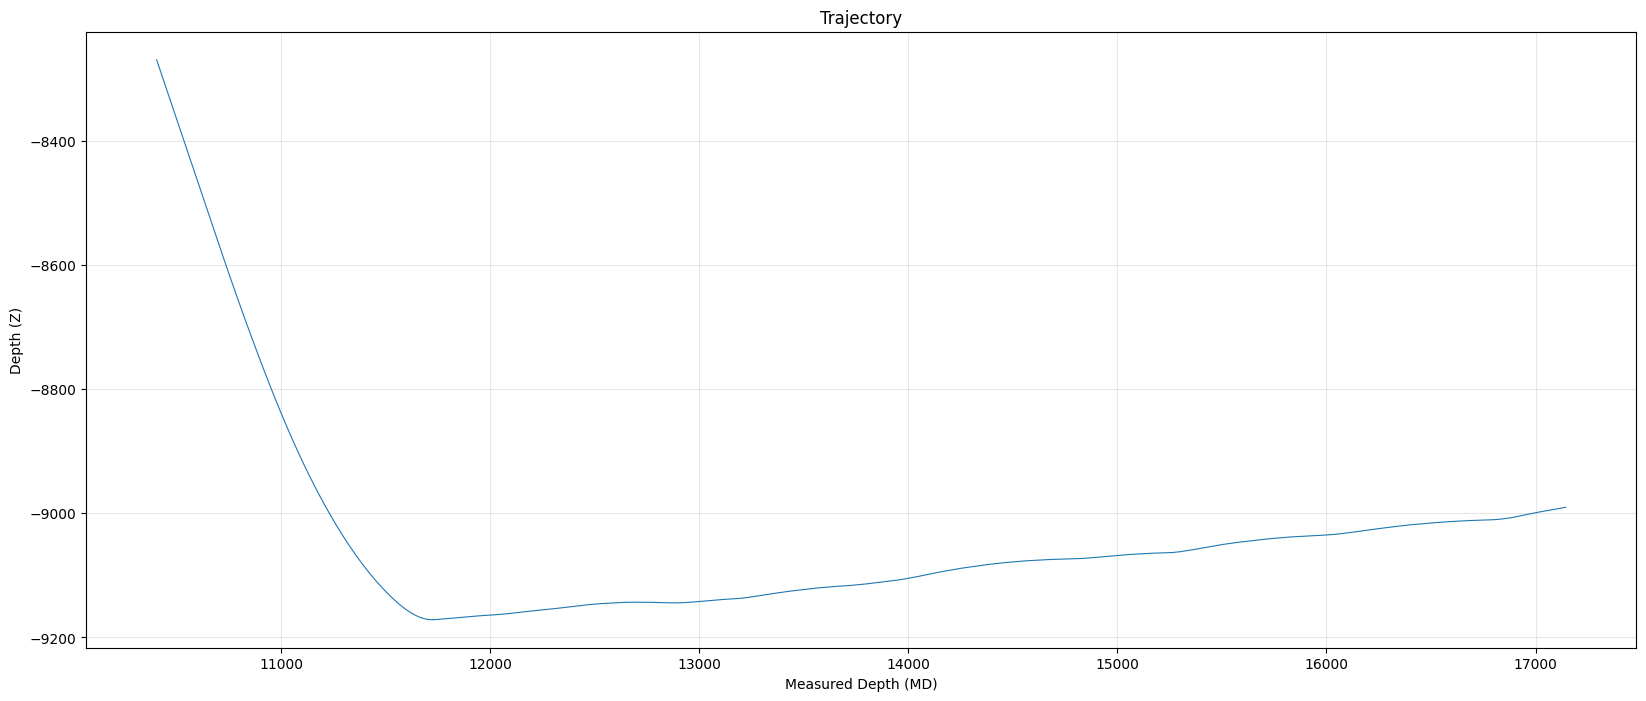

In [ ]:
# y against x
plot_x_y(h_df['MD'], h_df['Z'], "Measured Depth (MD)", "Depth (Z)", "Trajectory")

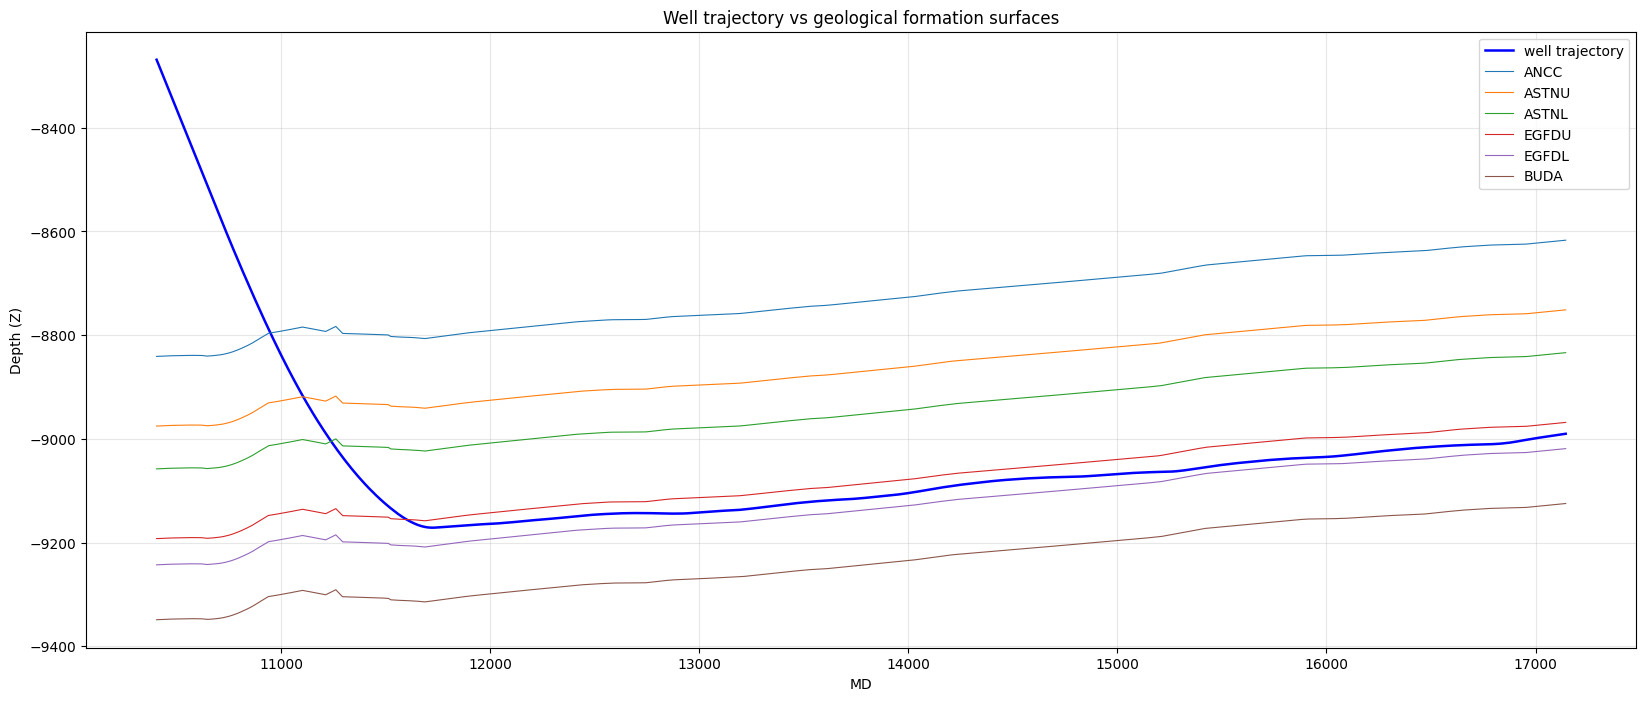

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(h_df['MD'], h_df['Z'], linewidth=1.8, label='well trajectory', color='blue')
plt.plot(h_df['MD'], h_df['ANCC'], linewidth=0.8, label='ANCC')
plt.plot(h_df['MD'], h_df['ASTNU'], linewidth=0.8, label='ASTNU')
plt.plot(h_df['MD'], h_df['ASTNL'], linewidth=0.8, label='ASTNL')
plt.plot(h_df['MD'], h_df['EGFDU'], linewidth=0.8, label='EGFDU')
plt.plot(h_df['MD'], h_df['EGFDL'], linewidth=0.8, label='EGFDL')
plt.plot(h_df['MD'], h_df['BUDA'], linewidth=0.8, label='BUDA')
plt.xlabel("MD")
plt.ylabel("Depth (Z)")
plt.title("Well trajectory vs geological formation surfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

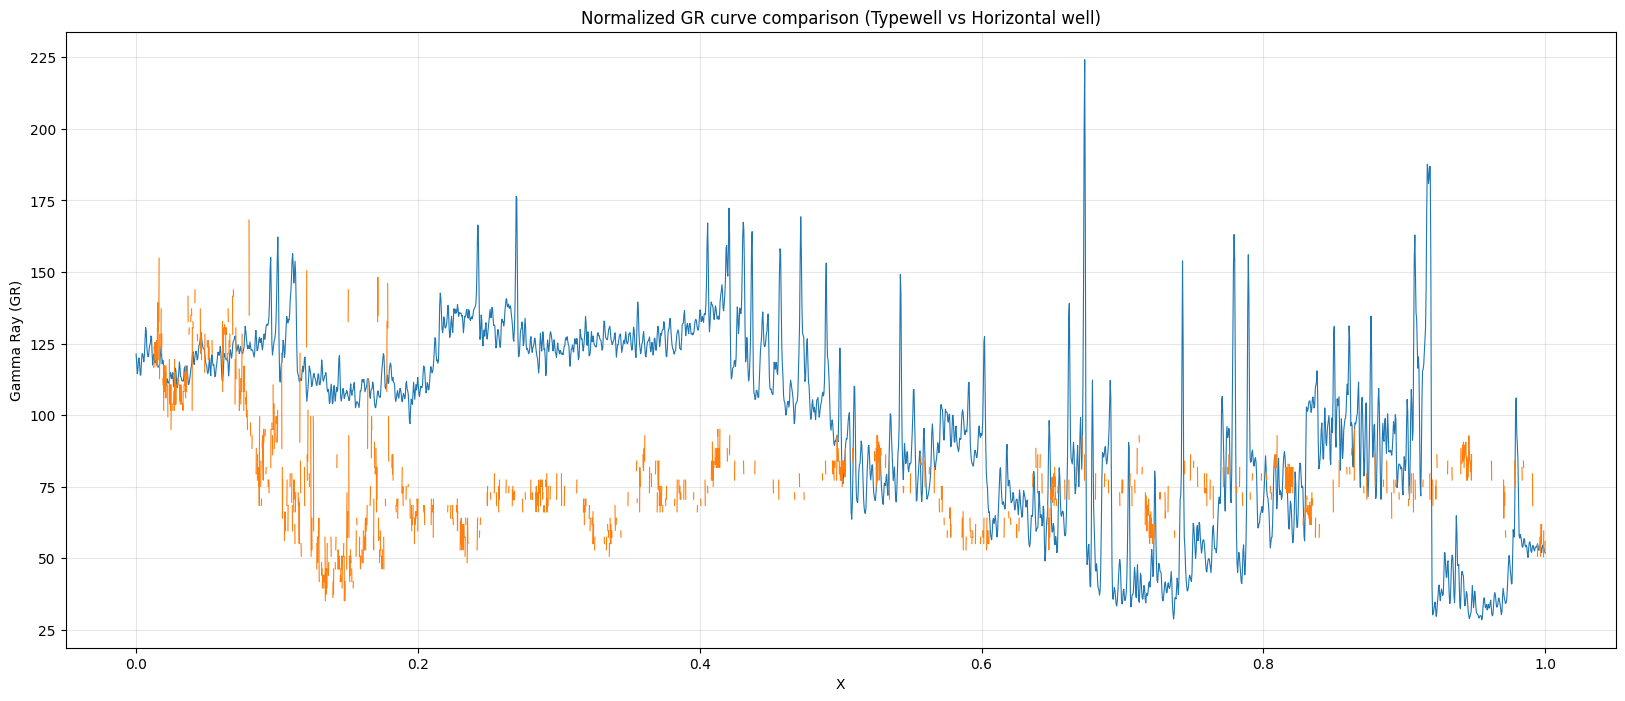

In [ ]:
# Quick visual check: do the two GR curves have a similar shape/pattern?
# This does NOT find the actual TVT match — it's just eyeballing texture before
# building the real sliding-window correlation function.

# normalising for a cleaner look
tw_norm = (tw_df['TVT']- tw_df['TVT'].min())/ (tw_df['TVT'].max() - tw_df['TVT'].min())
h_norm = (h_df['MD'] - h_df['MD'].min()) / (h_df['MD'].max() - h_df['MD'].min())

#plotting
plt.figure(figsize = (20,8))
plt.plot(tw_norm, tw_df['GR'], linewidth = 0.8 , label = 'Typewell GR')
plt.plot(h_norm, h_df['GR'], linewidth = 0.8, label = 'Horizontal Well GR')
plt.xlabel("X")
plt.ylabel("Gamma Ray (GR)")
plt.title("Normalized GR curve comparison (Typewell vs Horizontal well)")
plt.grid(True, alpha = 0.3)
plt.show()


# 3. Data Proprocessing

Before we can train anything, we need to turn each well's raw files into one clean table the model can actually learn from. Here's what we're doing for each well:

**Matching horizontal well points to the typewell.**
The horizontal well and typewell are two separate logs — they don't line up row by row, so we can't just merge them directly. Instead, we slide the horizontal well's GR curve across the typewell's GR curve to find where the patterns line up best (cross-correlation). Wherever we find a strong match, we grab the corresponding TVT from the typewell and attach it to that row, along with a score telling us how confident that match is.

**Adding a few engineered features.**
Since the data is sequential (each row depends a bit on the ones around it), we add some rolling-window features — basically local averages/trends over the last few rows — so the model gets a sense of what's happening nearby, not just at a single isolated point.

**Not bothering with missing values.**
There are NaNs scattered through the data, but we're not filling or dropping them — LightGBM handles missing values on its own during training, so it's one less thing to worry about.

**One exception: GR needs to be NaN-free just for the matching step.**
Cross-correlation breaks completely if there's even one NaN in the window, so we make a separate interpolated copy of GR purely to run the matching on. We don't touch the original GR column — that one keeps its real gaps and is what actually goes into the model.

In [ ]:
# function to normalize arrays
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

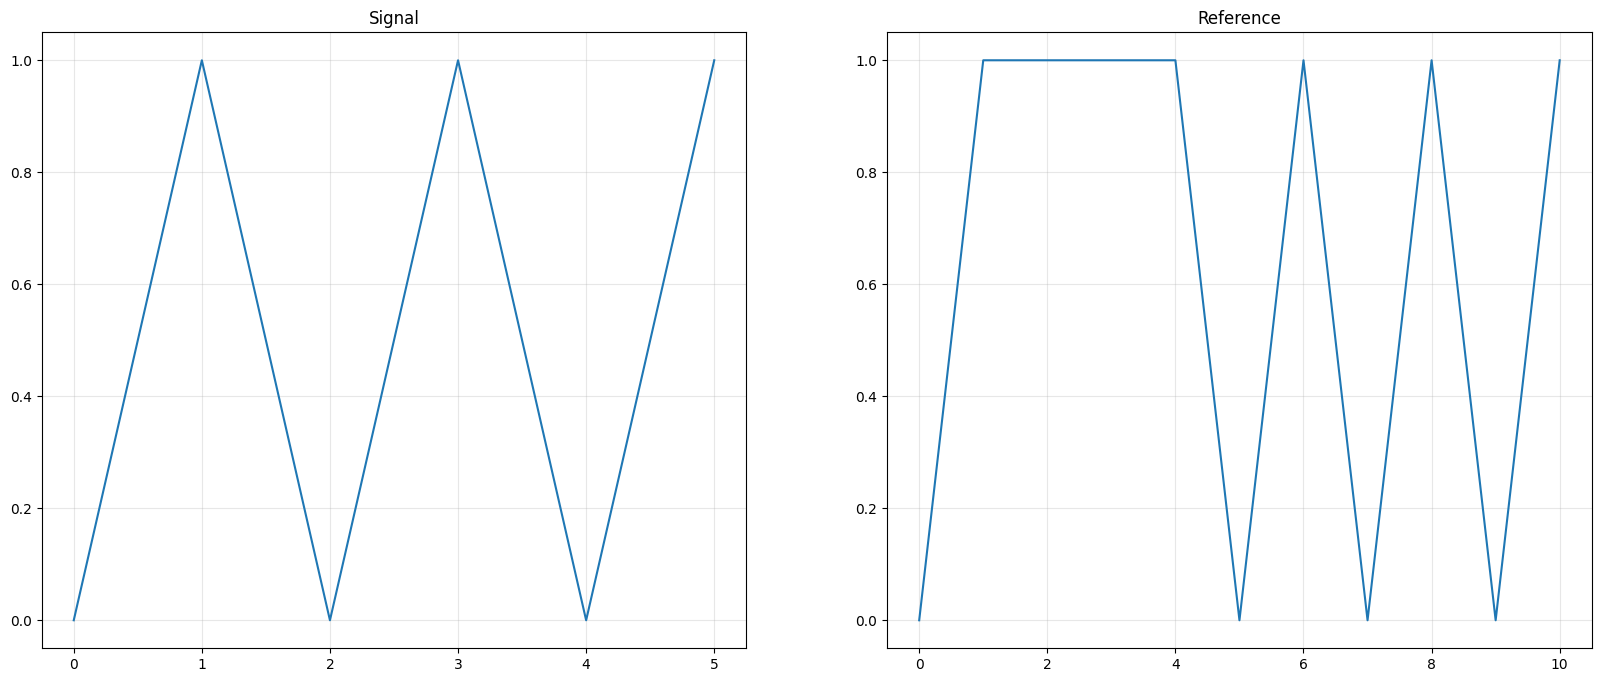

Correlation values:  [ 0.          2.07880452 -4.15760903  4.15760903 -6.23641355  6.23641355]
matched_place:  5


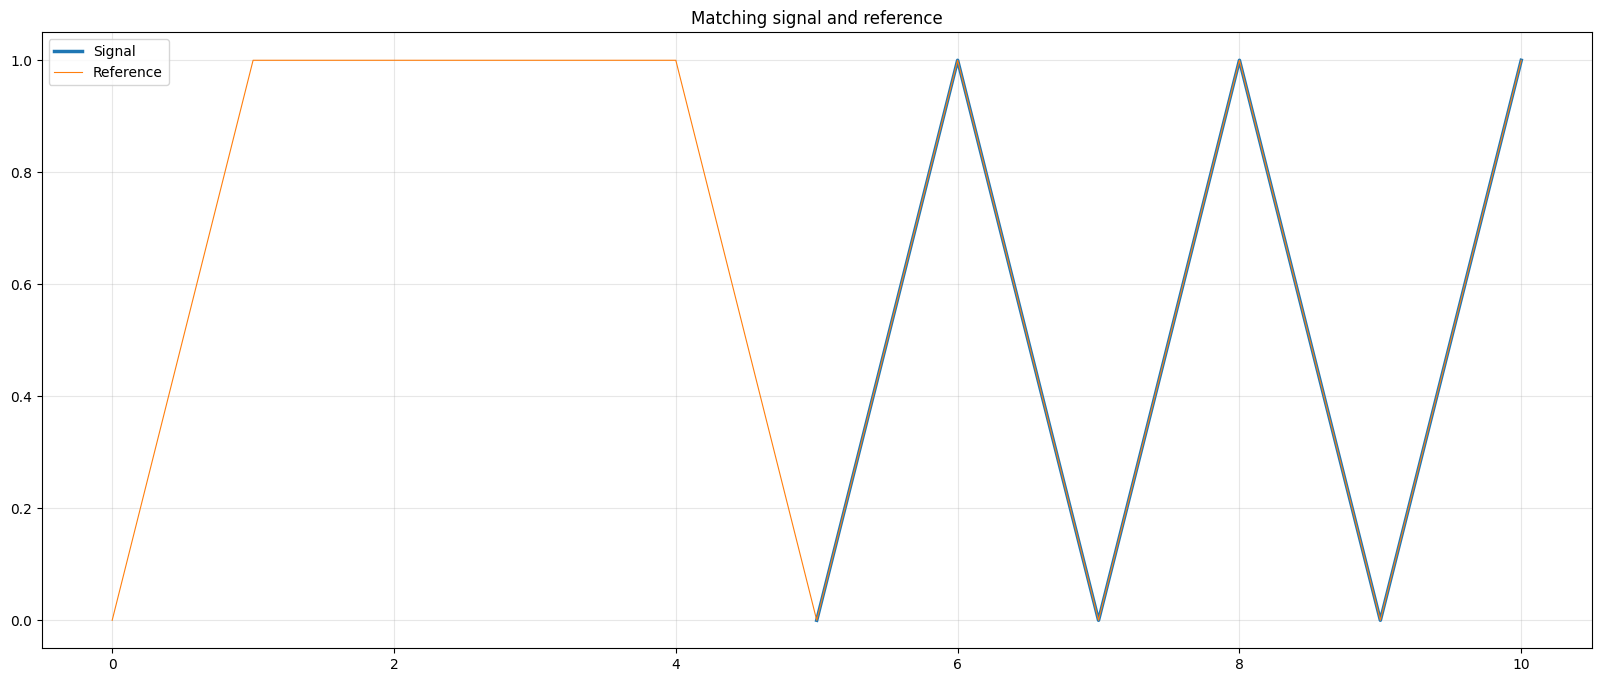

In [ ]:
# dummy example to understand scipy.signal.correlate()
signal = np.array([0,1,0,1,0,1], dtype = int)
reference = np.array([0,1,1,1,1,0,1,0,1,0,1], dtype = int) # where we are looking for similar patterns

# plotting the two before matching
plt.figure(figsize = (20,8))
plt.subplot(1,2,1)
plt.plot(signal)
plt.title("Signal")
plt.grid(True, alpha = 0.3)
plt.subplot(1,2,2)
plt.plot(reference)
plt.title("Reference")
plt.grid(True, alpha = 0.3)
plt.show()

n_signal = normalize(signal)
n_reference = normalize(reference)

corr = correlate(n_reference, n_signal, mode = 'valid')
print("Correlation values: ", corr)
matched_place = np.argmax(corr) # where the signal starts matching the reference
print("matched_place: ", matched_place)


# x axis
signal_x = np.arange(matched_place, matched_place + len(signal)) # this is for shifting to start from matched place
reference_x = np.arange(len(reference))

# plotting
plt.figure(figsize= (20,8))
plt.plot(signal_x, signal, linewidth = 2.5, label = 'Signal')
plt.plot(reference_x, reference, linewidth = 0.8, label = 'Reference')
plt.title("Matching signal and reference")
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

### Applying this to the real data.

We'll do the same thing with the actual GR values: use matched_place to find the corresponding index in the typewell, then pull out its TVT and assign it to that row in the horizontal well dataset.


The difference is we won't take the whole array of GR values — we'll slide a small window of GR values at a time, for more precision. Each window produces one matched TVT and one confidence/correlation score, which we'll store in two new columns: matched_tvt and match_score.


Since each window covers several rows but only produces one matched value, we'll assign that value to the center row of the window, rather than to every row it covers — that gives the most representative position for the match. Do not worry about the rest of Matched TVT rows, they will get filled as the window slides :)

In [ ]:
# creating a function to process each well datasets separately.
def process_well(h_df, tw_df):
    # remove nan from GR columns first for cross correlation
    h_GR_clean = h_df['GR'].interpolate(limit_direction = 'both')
    tw_GR_clean = tw_df['GR'].interpolate(limit_direction= 'both')

    norm_h_GR = normalize(h_GR_clean)
    norm_tw_GR = normalize(tw_GR_clean)

    # initialise the new columns in horizontal file
    # (We use temporary NumPy arrays here for lightning-fast loop writes)
    matched_TVT_arr = np.full(len(norm_h_GR), np.nan)
    matched_score_arr = np.full(len(norm_h_GR), np.nan)
    tw_TVT_arr = tw_df['TVT'].to_numpy() # Converted to array to avoid .iloc slowdown

    # cross-correlation
    for i in range(0,len(norm_h_GR)- WINDOW):
        h_seq = norm_h_GR[i:i + WINDOW]
        corr = correlate(norm_tw_GR, h_seq, mode = 'valid')
        matched_place = np.argmax(corr)
        confidence_score = corr[matched_place]
        centre = (i + WINDOW ) // 2


        # assign it to columns
        # (Writing to the NumPy arrays instead of using slower .loc and .iloc)
        matched_TVT_arr[centre] = tw_TVT_arr[(matched_place + WINDOW) // 2]
        matched_score_arr[centre] = confidence_score

    # Assign the fast arrays back to the DataFrame columns once the loop is done
    h_df['matched_TVT'] = matched_TVT_arr
    h_df['matched_score'] = matched_score_arr

    # add rolling window features
    #GR
    h_df['GR_mean'] = h_df['GR'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).mean()
    h_df['GR_std'] = h_df['GR'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).std()
    # later if we are not sure which rolling window value is the best, we run a loop to add features
    # with more options (e.g. 10, 20, 100) and let the model decide with feature importance!

    #Z slope
    h_df['Z_slope'] = h_df['Z'].diff(10) / h_df['MD'].diff(10)
    h_df['Z_slope_mean'] = h_df['Z_slope'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).mean()
    h_df['Z_slope_std'] = h_df['Z_slope'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).std()


    return h_df

In [ ]:
'''# process and concatenate all wells
df = []
for h_file in tqdm(HORIZONTAL_FILES):
    well_ID = os.path.basename(h_file).split("__")[0]
    tw_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    h_df = pd.read_csv(h_file)
    tw_df = pd.read_csv(tw_file)

    # process the data
    processed_df = process_well(h_df, tw_df)
    df.append(processed_df)

# concatenate everything
data = pd.concat(df, ignore_index = True)'''

'# process and concatenate all wells \ndf = []\nfor h_file in tqdm(HORIZONTAL_FILES):\n    well_ID = os.path.basename(h_file).split("__")[0]\n    tw_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")\n    h_df = pd.read_csv(h_file)\n    tw_df = pd.read_csv(tw_file)\n\n    # process the data \n    processed_df = process_well(h_df, tw_df)\n    df.append(processed_df)\n\n# concatenate everything \ndata = pd.concat(df, ignore_index = True)'

In [ ]:
'''data.head(50)'''

'data.head(50)'

In [ ]:
#data.shape

In [ ]:
'''# prepare the input to the models
X = data.drop(columns = ['TVT', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA'])
y = data['TVT']

# temp = test + val
X_train , X_temp,y_train ,  y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_test , X_val ,  y_test,y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

X_train = X_train.values
X_test = X_test.values
X_val = X_val.values
y_train = y_train.values
y_test = y_test.values
y_val = y_val.values

print("X_train shape: ", X_train.shape )
print("y_train shape: ", y_train.shape )
print("X_test shape: ", X_test.shape )
print("y_test shape: ", y_test.shape )
print("X_val shape: ", X_val.shape )
print("y_val shape: ",y_val.shape )'''

'# prepare the input to the models \nX = data.drop(columns = [\'TVT\', \'ANCC\', \'ASTNU\', \'ASTNL\', \'EGFDU\', \'EGFDL\', \'BUDA\'])\ny = data[\'TVT\']\n\n# temp = test + val \nX_train , X_temp,y_train ,  y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42)\nX_test , X_val ,  y_test,y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)\n\nX_train = X_train.values \nX_test = X_test.values \nX_val = X_val.values \ny_train = y_train.values \ny_test = y_test.values \ny_val = y_val.values \n\nprint("X_train shape: ", X_train.shape )\nprint("y_train shape: ", y_train.shape )\nprint("X_test shape: ", X_test.shape )\nprint("y_test shape: ", y_test.shape )\nprint("X_val shape: ", X_val.shape )\nprint("y_val shape: ",y_val.shape )'

# 4. Modeling

In [ ]:
!pip install catboost -q

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# check if a GPU is attached in this session - CatBoost can use it if so
catboost_gpu_available = False
try:
    import subprocess
    subprocess.check_output(['nvidia-smi'])
    catboost_gpu_available = True
except Exception:
    catboost_gpu_available = False
print("GPU available:", catboost_gpu_available)

GPU available: True


In [ ]:
# self-healing check: rebuild data/X with WELL_ID if it's missing for any reason
if 'data' not in dir() or 'WELL_ID' not in data.columns:
    print("data missing or missing WELL_ID - rebuilding now...")
    df = []
    for h_file in tqdm(HORIZONTAL_FILES):
        well_ID = os.path.basename(h_file).split("__")[0]
        tw_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
        h_df = pd.read_csv(h_file)
        tw_df = pd.read_csv(tw_file)
        h_df['WELL_ID'] = well_ID

        processed_df = process_well(h_df, tw_df)
        df.append(processed_df)

    data = pd.concat(df, ignore_index=True)

    X = data.drop(columns=['TVT', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA'])
    y = data['TVT']

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    X_train = X_train.values
    X_test = X_test.values
    X_val = X_val.values
    y_train = y_train.values
    y_test = y_test.values
    y_val = y_val.values

    print("rebuild done. WELL_ID in data:", 'WELL_ID' in data.columns)
else:
    print("data already has WELL_ID, continuing...")

# well-level split so sequence windows can't straddle train/test
well_ids = data['WELL_ID'].unique()
train_wells, temp_wells = train_test_split(well_ids, test_size=0.3, random_state=42)
val_wells, test_wells = train_test_split(temp_wells, test_size=0.5, random_state=42)

data_sorted = data.sort_values(['WELL_ID', 'MD']).reset_index(drop=True)
feature_cols = [c for c in X.columns if c != 'WELL_ID']

train_df = data_sorted[data_sorted['WELL_ID'].isin(train_wells)]
val_df   = data_sorted[data_sorted['WELL_ID'].isin(val_wells)]
test_df  = data_sorted[data_sorted['WELL_ID'].isin(test_wells)]

SEQ_LEN = 30

def build_well_sequences(df, feature_cols, seq_len):
    feats = df[feature_cols].fillna(0).values.astype('float32')
    target = df['TVT'].values.astype('float32')
    padded = np.vstack([np.zeros((seq_len - 1, feats.shape[1]), dtype='float32'), feats])
    windows = sliding_window_view(padded, seq_len, axis=0).transpose(0, 2, 1)
    return windows, target

def build_dataset_sequences(df, feature_cols, seq_len):
    X_list, y_list = [], []
    for well_id, group in tqdm(df.groupby('WELL_ID')):
        Xw, yw = build_well_sequences(group, feature_cols, seq_len)
        X_list.append(Xw)
        y_list.append(yw)
    return np.concatenate(X_list), np.concatenate(y_list)

X_train_seq, y_train_seq = build_dataset_sequences(train_df, feature_cols, SEQ_LEN)
X_val_seq, y_val_seq     = build_dataset_sequences(val_df, feature_cols, SEQ_LEN)
X_test_seq, y_test_seq   = build_dataset_sequences(test_df, feature_cols, SEQ_LEN)

feat_mean = X_train_seq.reshape(-1, X_train_seq.shape[-1]).mean(axis=0)
feat_std = X_train_seq.reshape(-1, X_train_seq.shape[-1]).std(axis=0) + 1e-8

X_train_seq_n = (X_train_seq - feat_mean) / feat_std
X_val_seq_n   = (X_val_seq - feat_mean) / feat_std
X_test_seq_n  = (X_test_seq - feat_mean) / feat_std

print("X_train_seq shape:", X_train_seq.shape)

data missing or missing WELL_ID - rebuilding now...


  0%|          | 0/773 [00:00<?, ?it/s]

rebuild done. WELL_ID in data: True


  0%|          | 0/541 [00:00<?, ?it/s]

  0%|          | 0/116 [00:00<?, ?it/s]

  0%|          | 0/116 [00:00<?, ?it/s]

X_train_seq shape: (3564218, 30, 13)


In [ ]:
cat_features = [X.columns.get_loc('WELL_ID')]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val,  cat_features=cat_features)

cb_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=200,
    task_type='GPU' if catboost_gpu_available else 'CPU',
    verbose=200
)
cb_model.fit(train_pool, eval_set=val_pool, use_best_model=True)

cb_preds = cb_model.predict(X_test)
mae = mean_absolute_error(y_test, cb_preds)
rmse = mean_squared_error(y_test, cb_preds) ** 0.5
r2 = r2_score(y_test, cb_preds)
print(f"CatBoost -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")

0:	learn: 621.8575227	test: 621.6253543	best: 621.6253543 (0)	total: 396ms	remaining: 26m 23s
200:	learn: 65.3806437	test: 64.6314532	best: 64.6314532 (200)	total: 56.2s	remaining: 17m 43s
400:	learn: 44.5075459	test: 43.6884578	best: 43.6884578 (400)	total: 1m 52s	remaining: 16m 48s
600:	learn: 33.1470342	test: 32.3226213	best: 32.3226213 (600)	total: 2m 49s	remaining: 15m 58s
800:	learn: 26.8083848	test: 26.0595417	best: 26.0595417 (800)	total: 3m 45s	remaining: 15m 1s
1000:	learn: 22.8503543	test: 22.1045970	best: 22.1045970 (1000)	total: 4m 41s	remaining: 14m 4s
1200:	learn: 20.0571390	test: 19.3248341	best: 19.3248341 (1200)	total: 5m 37s	remaining: 13m 6s
1400:	learn: 18.0036094	test: 17.3012429	best: 17.3012429 (1400)	total: 6m 34s	remaining: 12m 11s
1600:	learn: 16.2475451	test: 15.6222869	best: 15.6222869 (1600)	total: 7m 31s	remaining: 11m 16s
1800:	learn: 14.9690754	test: 14.3757129	best: 14.3757129 (1800)	total: 8m 28s	remaining: 10m 20s
2000:	learn: 13.8206404	test: 13.284

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)

n_train, n_val, n_test = 2000, 400, 400
n_features_tab = 10        # number of tabular features for CatBoost
timesteps = 20             # sequence length for LSTM/GRU
n_features_seq = 5         # number of features per timestep

feature_cols = [f"feat_{i}" for i in range(n_features_tab)]

def make_df(n):
    df = pd.DataFrame(np.random.randn(n, n_features_tab), columns=feature_cols)
    df['TVT'] = df[feature_cols].sum(axis=1) + np.random.randn(n) * 0.5
    return df

train_df = make_df(n_train)
val_df   = make_df(n_val)
test_df  = make_df(n_test)

def make_seq(n):
    X = np.random.randn(n, timesteps, n_features_seq)
    y = X.sum(axis=(1, 2)) / timesteps + np.random.randn(n) * 0.5
    return X.astype('float32'), y.astype('float32')

X_train_seq_n, y_train_seq = make_seq(n_train)
X_val_seq_n,   y_val_seq   = make_seq(n_val)
X_test_seq_n,  y_test_seq  = make_seq(n_test)


n_timesteps, n_features = X_train_seq_n.shape[1], X_train_seq_n.shape[2]

lstm_model = keras.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(
    X_train_seq_n, y_train_seq,
    validation_data=(X_val_seq_n, y_val_seq),
    epochs=20, batch_size=64,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)
lstm_preds = lstm_model.predict(X_test_seq_n, verbose=0, batch_size=512).flatten()


gru_model = keras.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),
    layers.GRU(64, return_sequences=True),
    layers.GRU(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(
    X_train_seq_n, y_train_seq,
    validation_data=(X_val_seq_n, y_val_seq),
    epochs=20, batch_size=64,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)


required_vars = ['gru_model', 'X_val_seq_n', 'X_test_seq_n',
                  'lstm_model', 'lstm_preds', 'y_test_seq',
                  'train_df', 'val_df', 'test_df', 'feature_cols']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing from memory: {missing}.")

for df_name, df in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
    missing_cols = [c for c in feature_cols + ['TVT'] if c not in df.columns]
    if missing_cols:
        raise KeyError(f"{df_name} is missing columns: {missing_cols}")
    n_nan = df[feature_cols + ['TVT']].isna().sum().sum()
    if n_nan > 0:
        raise ValueError(f"{df_name} has {n_nan} NaN values in feature_cols/TVT.")

cb_stack_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.03, depth=6, l2_leaf_reg=3,
    loss_function='RMSE', eval_metric='RMSE',
    random_seed=42, early_stopping_rounds=100, verbose=200
)
cb_stack_model.fit(
    Pool(train_df[feature_cols], train_df['TVT']),
    eval_set=Pool(val_df[feature_cols], val_df['TVT']),
    use_best_model=True
)

cb_val_preds = cb_stack_model.predict(val_df[feature_cols])
cb_test_preds = cb_stack_model.predict(test_df[feature_cols])

gru_val_preds = gru_model.predict(X_val_seq_n, verbose=0, batch_size=512).flatten()
gru_test_preds = gru_model.predict(X_test_seq_n, verbose=0, batch_size=512).flatten()

lstm_val_preds = lstm_model.predict(X_val_seq_n, verbose=0, batch_size=512).flatten()


val_lengths = {'val_df': len(val_df), 'cb_val_preds': len(cb_val_preds),
               'gru_val_preds': len(gru_val_preds), 'lstm_val_preds': len(lstm_val_preds)}
if len(set(val_lengths.values())) > 1:
    raise ValueError(f"Validation length mismatch: {val_lengths}")

test_lengths = {'test_df': len(test_df), 'cb_test_preds': len(cb_test_preds),
                'gru_test_preds': len(gru_test_preds), 'lstm_preds': len(lstm_preds),
                'y_test_seq': len(y_test_seq)}
if len(set(test_lengths.values())) > 1:
    raise ValueError(f"Test length mismatch: {test_lengths}")


meta_model = RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0])
meta_model.fit(
    np.column_stack([cb_val_preds, gru_val_preds, lstm_val_preds]),
    val_df['TVT'].values
)
print(f"RidgeCV selected alpha: {meta_model.alpha_}")

stacked_preds = meta_model.predict(
    np.column_stack([cb_test_preds, gru_test_preds, lstm_preds])
)


y_test_true = test_df['TVT'].values
results = [
    ("CatBoost only", cb_test_preds, y_test_true),
    ("GRU only", gru_test_preds, y_test_true),
    ("LSTM only", lstm_preds, y_test_seq),
    ("Stacked (CatBoost+GRU+LSTM)", stacked_preds, y_test_true)
]
for name, preds, yt in results:
    mae = mean_absolute_error(yt, preds)
    rmse = mean_squared_error(yt, preds) ** 0.5
    r2 = r2_score(yt, preds)
    print(f"{name:28s} -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")

I0000 00:00:1791569859.099089      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13754 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791569859.108328      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13754 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.3373 - val_loss: 0.2488
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2733 - val_loss: 0.2320
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2666 - val_loss: 0.2283
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2580 - val_loss: 0.2325
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2533 - val_loss: 0.2255
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2532 - val_loss: 0.2316
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2490 - val_loss: 0.2238
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2498 - val_loss: 0.2380
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2484 - val_loss: 0.2350
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2481 - val_loss: 0.2344
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2448 - val_loss: 0.2277
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2

In [ ]:
!pip freeze > requirements.txt